# 03 — Classical baseline: HOG + SVM

We describe each greyscale steel image by its local edge directions (HOG), then learn how these descriptions distinguish the six defect classes using an SVM. This is the handcrafted-representation baseline for comparison with the later CNN.

**Development only:** 1,439 images and the five saved folds. This notebook never opens test images or evaluates the test partition. Run notebooks 02 and 02a successfully first, then restart the kernel and run all cells here from the project root.

Install first:
```bat
venv\Scripts\python.exe -m pip install numpy pandas matplotlib pillow scikit-image scikit-learn joblib ipykernel
```

All core logic is included here. At submission consolidation it will follow the inlined split and fold sections; no private Python modules are required. Each execution writes a separate run directory and records every candidate, rather than overwriting previous experiments.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
from importlib.metadata import version
import hashlib
import json
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from skimage.feature import hog
from skimage.exposure import rescale_intensity
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.exceptions import ConvergenceWarning
import joblib

ROOT = Path.cwd().resolve()
METRICS = ROOT / 'outputs' / 'metrics'
REPORTS = ROOT / 'outputs' / 'reports'
CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
SEED = 42
def require(condition, message):
    if not bool(condition): raise RuntimeError(message)
def digest(path): return hashlib.sha256(path.read_bytes()).hexdigest()
def read_json(path): return json.loads(path.read_text(encoding='utf-8'))

paths = {'manifest': METRICS/'data_split_manifest.csv', 'split_lock': METRICS/'split_lock.json',
         'folds': METRICS/'development_cv_folds.csv', 'fold_lock': METRICS/'development_cv_lock.json',
         'split_status': REPORTS/'02_split_status.json', 'fold_status': REPORTS/'02a_validation_status.json'}
require(all(p.is_file() for p in paths.values()), 'Run notebooks 02 and 02a first.')
source_digests = {key: digest(path) for key, path in paths.items()}
lock, fold_lock = read_json(paths['split_lock']), read_json(paths['fold_lock'])
split_status, fold_status = read_json(paths['split_status']), read_json(paths['fold_status'])
require(split_status['status'] == fold_status['status'] == 'PASS', 'Preparation checks have not passed.')
require(source_digests['manifest'] == lock['manifest_sha256'] == fold_lock['split_manifest_sha256']
        == split_status['manifest_sha256'] == fold_status['split_manifest_sha256'], 'Split checksum mismatch.')
require(source_digests['folds'] == fold_lock['folds_sha256'] == fold_status['folds_sha256'], 'Fold checksum mismatch.')
require(lock['classes'] == CLASSES and lock['seed'] == fold_lock['seed'] == SEED
        and fold_lock['n_folds'] == 5, 'Unexpected split/fold policy.')
manifest = pd.read_csv(paths['manifest'], keep_default_na=False)
folds = pd.read_csv(paths['folds'], keep_default_na=False)
require(manifest.path.is_unique and folds.path.is_unique, 'Repeated image path.')
development = manifest.loc[manifest.split.eq('development')].sort_values('path').reset_index(drop=True)
require(len(development) == 1439 and set(development.class_name) == set(CLASSES), 'Unexpected development data.')
require(set(folds.path) == set(development.path), 'Fold table does not exactly cover development.')
folds = folds.set_index('path').loc[development.path].reset_index()
for key in ['path', 'class_name', 'sha256', 'pixel_sha256']:
    require(folds[key].equals(development[key]), f'Fold metadata mismatch: {key}')
development['validation_fold'] = folds.validation_fold.to_numpy()
require(set(development.validation_fold) == set(range(5)), 'Invalid validation folds.')
test_metadata = manifest.loc[manifest.split.eq('test')]
for key in ['path', 'sha256', 'pixel_sha256']:
    require(development[key].is_unique and not (set(development[key]) & set(test_metadata[key])), f'Duplicate/leakage: {key}')
cv=[]
for fold in range(5):
    train=np.flatnonzero(development.validation_fold.to_numpy() != fold)
    valid=np.flatnonzero(development.validation_fold.to_numpy() == fold)
    require(set(development.iloc[train].class_name) == set(development.iloc[valid].class_name) == set(CLASSES), 'Missing fold class.')
    require(not set(train) & set(valid), 'Overlapping fold indices.')
    cv.append((train, valid))
require(np.array_equal(np.sort(np.concatenate([v for _,v in cv])), np.arange(len(development))), 'OOF coverage is not exact.')
print('PASS: verified split and five development folds; test image files have not been opened.')

PASS: verified split and five development folds; test image files have not been opened.


## 1. Declare the experiment before fitting

Keep native 200 × 200 resolution; convert to greyscale float32 intensities in [0, 1]. Fixed HOG: 9 orientation bins, 16 × 16 pixel cells, 2 × 2 cell blocks and L2-Hys block normalisation. This gives a manageable 4,356 features per image. The 200-pixel side is not divisible by 16: HOG uses 12 complete cells, so incomplete border cells are not represented. This is an explicit baseline limitation, not an optimised descriptor.

Compare **six candidates**: linear and RBF kernels, each with C = 0.1, 1, 10; RBF gamma = `scale`. HOG settings are fixed for this milestone. Select the highest **mean fold macro F1**. Exact ties retain declared candidate order (linear first, smaller C first). This bounded search is not evidence that the global optimum was found.

Each fold gets a new scaler and SVM. The scaler is fitted only on that fold's training images. HOG itself is deterministic per image and learns no population statistics, so it can be extracted once before CV. No augmentation, PCA or test-based decisions are used.

In [2]:
HOG_CONFIG = dict(orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2),
                  block_norm='L2-Hys', transform_sqrt=False, feature_vector=True, channel_axis=None)
CANDIDATES = [{'kernel': kernel, 'C': c, 'gamma': 'scale'}
              for kernel in ['linear','rbf'] for c in [0.1,1.0,10.0]]
run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN = ROOT/'outputs'/'experiments'/('03_hog_svm_'+run_id)
RUN.mkdir(parents=True, exist_ok=False)
environment = {'python': platform.python_version(), 'executable': sys.executable,
               'platform': platform.platform(), 'processor': platform.processor(),
               'packages': {p: version(p) for p in ['numpy','pandas','matplotlib','pillow','scikit-image','scikit-learn','joblib']}}
protocol = {'run_id':run_id, 'seed':SEED, 'source_digests':source_digests,
            'input_size':[200,200], 'grayscale':'Pillow L / 255, float32', 'hog':HOG_CONFIG,
            'candidates':CANDIDATES, 'selection_metric':'mean five-fold macro F1',
            'tie_break':'declared candidate order', 'environment':environment,
            'scope':'development only; test evaluation deferred'}
(RUN/'protocol.json').write_text(json.dumps(protocol,indent=2),encoding='utf-8')
(RUN/'status.json').write_text(json.dumps({'status':'IN_PROGRESS'}),encoding='utf-8')
print('Run folder:', RUN)
display(pd.DataFrame(CANDIDATES))

Run folder: C:\Scripts\industrial-defect-intelligence\outputs\experiments\03_hog_svm_20260923T232217_532748Z


,kernel,C,gamma
0,linear,0.1,scale
1,linear,1.0,scale
2,linear,10.0,scale
3,rbf,0.1,scale
4,rbf,1.0,scale
5,rbf,10.0,scale


HOG shape: (1439, 4356); matrix: 23.9 MiB; extraction + integrity checks: 18.69s


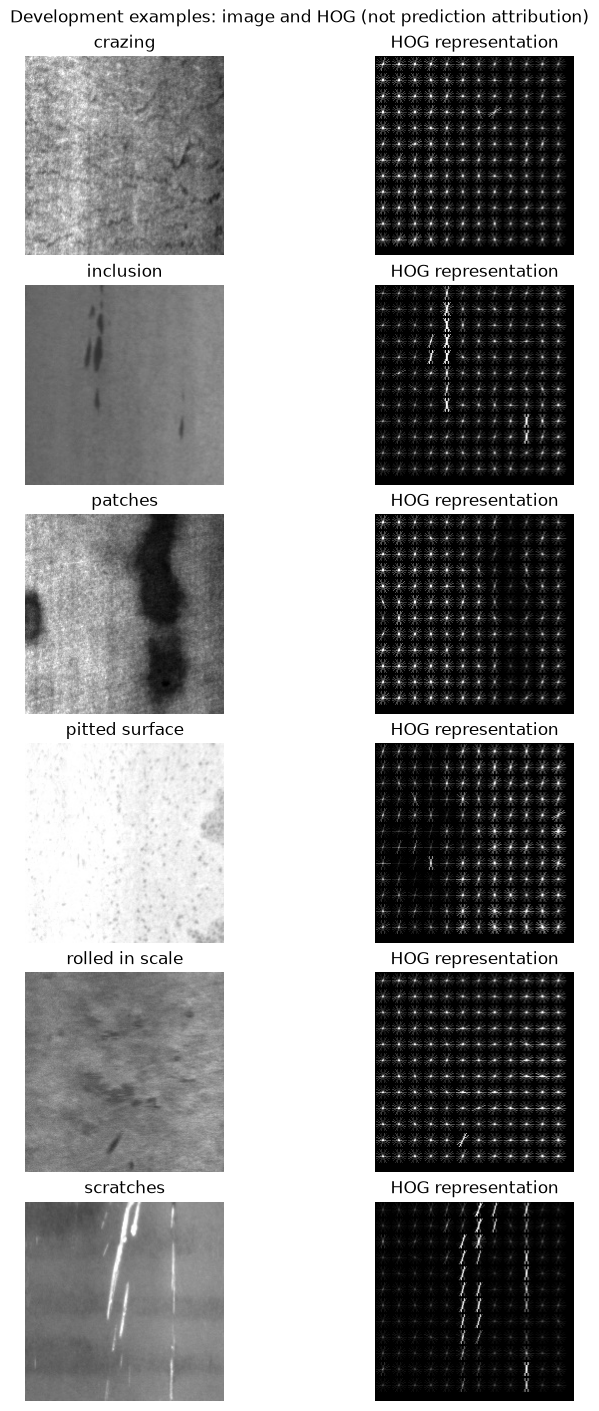

In [3]:
opened_paths=set()
allowed_paths=set(development.path)
def load_development_image(relative_path):
    require(relative_path in allowed_paths, 'Attempt to load a non-development image.')
    path=(ROOT/relative_path).resolve()
    require(path.is_relative_to((ROOT/'data'/'NEU-CLS').resolve()), 'Image path outside dataset.')
    with Image.open(path) as image:
        require(image.size == (200,200), 'Unexpected image dimensions.')
        array=np.asarray(image.convert('L'),dtype=np.float32)/255.0
    opened_paths.add(relative_path)
    return array

start=perf_counter()
features=[]
for row in development.itertuples():
    require(digest(ROOT/row.path) == row.sha256, f'Changed development image: {row.path}')
    features.append(hog(load_development_image(row.path), **HOG_CONFIG))
X=np.asarray(features,dtype=np.float32)
y=development.class_name.to_numpy()
feature_seconds=perf_counter()-start
require(X.shape == (1439,4356) and np.isfinite(X).all(), f'Invalid HOG matrix: {X.shape}')
print(f'HOG shape: {X.shape}; matrix: {X.nbytes/1024**2:.1f} MiB; extraction + integrity checks: {feature_seconds:.2f}s')

fig, axes=plt.subplots(6,2,figsize=(7,14),layout='constrained')
for index, label in enumerate(CLASSES):
    path=development.loc[development.class_name.eq(label),'path'].iloc[0]
    arr=load_development_image(path)
    _, visual=hog(arr,visualize=True,**HOG_CONFIG)
    axes[index,0].imshow(arr,cmap='gray',vmin=0,vmax=1)
    axes[index,1].imshow(rescale_intensity(visual,in_range=(0,float(np.percentile(visual,99.5)))),cmap='gray')
    axes[index,0].set_title(label.replace('_',' '))
    axes[index,1].set_title('HOG representation')
    for ax in axes[index]: ax.axis('off')
fig.suptitle('Development examples: image and HOG (not prediction attribution)')
fig.savefig(RUN/'hog_examples.png',dpi=130)
plt.show()
plt.close(fig)

## 2. Five-fold model selection

Accuracy measures the fraction correctly classified. Macro precision, recall and F1 give each class equal weight. Report sample standard deviation across the five fold scores as descriptive variation, **not a confidence interval**: their training sets overlap. The same folds guide selection, so the selected scores and pooled out-of-fold diagnostics can be optimistic. They are development results, not final test results or nested-CV estimates.

In [4]:
def make_model(params):
    return Pipeline([('scale',StandardScaler()),
                     ('svm',SVC(**params,cache_size=256,random_state=SEED))])
def metrics(truth,prediction):
    precision,recall,f1,_=precision_recall_fscore_support(truth,prediction,labels=CLASSES,average='macro',zero_division=0)
    return {'accuracy':accuracy_score(truth,prediction),'precision_macro':precision,
            'recall_macro':recall,'f1_macro':f1}

rows=[]
candidate_predictions={}
search_start=perf_counter()
for candidate_id,params in enumerate(CANDIDATES):
    oof=np.full(len(y),'',dtype=object)
    for fold,(train,valid) in enumerate(cv):
        model=make_model(params)
        start=perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter('error',ConvergenceWarning)
            model.fit(X[train],y[train])
        fit_seconds=perf_counter()-start
        require(int(model.named_steps['scale'].n_samples_seen_) == len(train), 'Scaler trained on wrong sample count.')
        require(np.allclose(model.named_steps['scale'].mean_, X[train].mean(axis=0,dtype=np.float64)), 'Scaler statistics mismatch.')
        start=perf_counter()
        prediction=model.predict(X[valid])
        predict_seconds=perf_counter()-start
        oof[valid]=prediction
        rows.append({'candidate_id':candidate_id,**params,'fold':fold,'train_images':len(train),
                     'validation_images':len(valid),**metrics(y[valid],prediction),
                     'fit_seconds':fit_seconds,'predict_seconds':predict_seconds})
        pd.DataFrame(rows).to_csv(RUN/'cv_fold_metrics.csv',index=False)
        print(f'Candidate {candidate_id+1}/6, fold {fold+1}/5: macro F1={rows[-1]["f1_macro"]:.4f}; fit={fit_seconds:.1f}s',flush=True)
    require(np.isin(oof,CLASSES).all(), 'Missing OOF predictions.')
    candidate_predictions[candidate_id]=oof
search_seconds=perf_counter()-search_start
fold_metrics=pd.DataFrame(rows)
summary=[]
for candidate_id,params in enumerate(CANDIDATES):
    group=fold_metrics.loc[fold_metrics.candidate_id.eq(candidate_id)]
    result={'candidate_id':candidate_id,**params}
    for metric in ['accuracy','precision_macro','recall_macro','f1_macro']:
        result[metric+'_mean']=group[metric].mean()
        result[metric+'_std']=group[metric].std(ddof=1)
    result['fit_seconds_total']=group.fit_seconds.sum()
    summary.append(result)
summary=pd.DataFrame(summary).sort_values(['f1_macro_mean','candidate_id'],ascending=[False,True])
summary.to_csv(RUN/'cv_candidate_summary.csv',index=False)
best_id=int(summary.iloc[0].candidate_id)
best_params=CANDIDATES[best_id]
selected_folds=fold_metrics.loc[fold_metrics.candidate_id.eq(best_id)].copy()
selected_folds.to_csv(RUN/'selected_fold_metrics.csv',index=False)
display(summary)
print('Selected configuration:',best_params)

Candidate 1/6, fold 1/5: macro F1=0.8408; fit=5.0s
Candidate 1/6, fold 2/5: macro F1=0.8175; fit=5.0s
Candidate 1/6, fold 3/5: macro F1=0.8462; fit=5.7s
Candidate 1/6, fold 4/5: macro F1=0.8276; fit=5.1s
Candidate 1/6, fold 5/5: macro F1=0.8276; fit=6.9s
Candidate 2/6, fold 1/5: macro F1=0.8408; fit=7.5s
Candidate 2/6, fold 2/5: macro F1=0.8175; fit=5.7s
Candidate 2/6, fold 3/5: macro F1=0.8462; fit=5.4s
Candidate 2/6, fold 4/5: macro F1=0.8276; fit=5.4s
Candidate 2/6, fold 5/5: macro F1=0.8276; fit=5.0s
Candidate 3/6, fold 1/5: macro F1=0.8408; fit=1.8s
Candidate 3/6, fold 2/5: macro F1=0.8175; fit=2.8s
Candidate 3/6, fold 3/5: macro F1=0.8462; fit=5.1s
Candidate 3/6, fold 4/5: macro F1=0.8276; fit=4.9s
Candidate 3/6, fold 5/5: macro F1=0.8276; fit=4.8s
Candidate 4/6, fold 1/5: macro F1=0.7277; fit=8.7s
Candidate 4/6, fold 2/5: macro F1=0.7612; fit=10.0s
Candidate 4/6, fold 3/5: macro F1=0.6656; fit=8.5s
Candidate 4/6, fold 4/5: macro F1=0.7117; fit=6.9s
Candidate 4/6, fold 5/5: macro

,candidate_id,kernel,C,gamma,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fit_seconds_total
5,5,rbf,10.0,scale,0.888804,0.012121,0.891109,0.011046,0.888697,0.012242,0.887114,0.012463,37.209770
4,4,rbf,1.0,scale,0.879769,0.010718,0.882506,0.011185,0.879684,0.010840,0.877231,0.011219,34.746623
0,0,linear,0.1,scale,0.833909,0.011415,0.836829,0.009383,0.833762,0.011495,0.831926,0.011481,27.723069
1,1,linear,1.0,scale,0.833909,0.011415,0.836829,0.009383,0.833762,0.011495,0.831926,0.011481,29.045967
2,2,linear,10.0,scale,0.833909,0.011415,0.836829,0.009383,0.833762,0.011495,0.831926,0.011481,19.409438
3,3,rbf,0.1,scale,0.731734,0.031577,0.755115,0.033476,0.731472,0.031942,0.709126,0.038219,43.364317


Selected configuration: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}


## 3. Development diagnostics

Every prediction below came from a model that excluded that image from fitting. However, the winning configuration was chosen using these same folds; these plots help diagnose development behaviour and must not be presented as untouched final evaluation. No SVM probabilities are claimed. Probability estimation is left disabled by default; the deprecated `probability` argument is omitted. Historical outputs may show the warning from the earlier explicit setting; it did not invalidate those results.

,precision,recall,f1-score,support
crazing,0.859712,0.995833,0.922780,240.000000
inclusion,0.847059,0.900000,0.872727,240.000000
patches,0.915842,0.774059,0.839002,239.000000
pitted_surface,0.841629,0.775000,0.806941,240.000000
rolled_in_scale,0.995851,1.000000,0.997921,240.000000
scratches,0.880165,0.887500,0.883817,240.000000
accuracy,0.888812,0.888812,0.888812,0.888812
macro avg,0.890043,0.888732,0.887198,1439.000000
weighted avg,0.890025,0.888812,0.887232,1439.000000


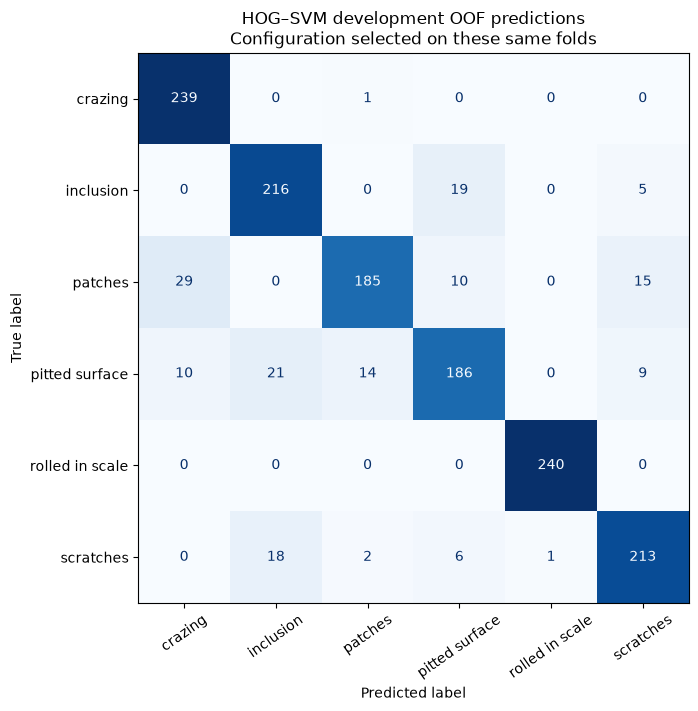

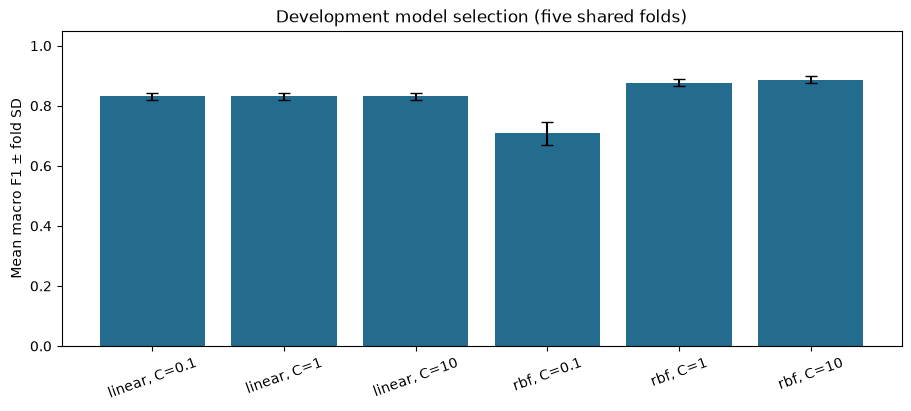

In [5]:
oof=candidate_predictions[best_id]
predictions=development[['path','class_name','validation_fold']].copy()
predictions['predicted_class']=oof
predictions['correct']=predictions.class_name.eq(predictions.predicted_class)
predictions.to_csv(RUN/'selected_oof_predictions.csv',index=False)
report=pd.DataFrame(classification_report(y,oof,labels=CLASSES,output_dict=True,zero_division=0)).T
report.to_csv(RUN/'selected_oof_classification_report.csv')
display(report)
cm=confusion_matrix(y,oof,labels=CLASSES)
pd.DataFrame(cm,index=CLASSES,columns=CLASSES).to_csv(RUN/'selected_oof_confusion_matrix.csv')
fig,ax=plt.subplots(figsize=(9,7),layout='constrained')
ConfusionMatrixDisplay(cm,display_labels=[c.replace('_',' ') for c in CLASSES]).plot(ax=ax,cmap='Blues',colorbar=False,xticks_rotation=35)
ax.set_title('HOG–SVM development OOF predictions\nConfiguration selected on these same folds')
fig.savefig(RUN/'development_oof_confusion_matrix.png',dpi=150)
plt.show()
plt.close(fig)
fig,ax=plt.subplots(figsize=(9,4),layout='constrained')
ordered=summary.sort_values('candidate_id')
ax.bar(range(len(ordered)),ordered.f1_macro_mean,yerr=ordered.f1_macro_std,capsize=4,color='#246c8e')
ax.set_xticks(range(len(ordered)),[f'{r.kernel}, C={r.C:g}' for r in ordered.itertuples()],rotation=20)
ax.set(ylabel='Mean macro F1 ± fold SD',ylim=(0,1.05),title='Development model selection (five shared folds)')
fig.savefig(RUN/'cv_candidate_comparison.png',dpi=150)
plt.show()
plt.close(fig)

## 4. Refit the selected configuration on all development data

Refit once on all 1,439 development examples and save the fitted scaler/SVM plus HOG configuration. Test evaluation remains deferred until the CNN protocol and model are finalised. The saved model takes HOG vectors; future inference must apply the identical greyscale and HOG steps first. Only load joblib files from trusted sources.

Timing scope: feature extraction includes image reads and integrity checks; CV fit times include scaling and SVM training; prediction times use already-computed HOG features. These are not end-to-end deployment latency benchmarks. Store them separately for a fair later comparison with CNN preprocessing and inference.

In [6]:
final_model=make_model(best_params)
start=perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter('error',ConvergenceWarning)
    final_model.fit(X,y)
final_fit_seconds=perf_counter()-start
require(int(final_model.named_steps['scale'].n_samples_seen_) == 1439, 'Final fit size mismatch.')
model_path=RUN/'hog_svm_development.joblib'
joblib.dump({'pipeline':final_model,'hog_config':HOG_CONFIG,'classes':CLASSES,
             'input_size':(200,200),'grayscale':'Pillow L / 255, float32',
             'split_manifest_sha256':source_digests['manifest'],
             'folds_sha256':source_digests['folds'],'selected_params':best_params},model_path,compress=3)
# Small serialization check; this is not a training-set performance report.
loaded=joblib.load(model_path)
require(np.array_equal(final_model.predict(X[:6]),loaded['pipeline'].predict(X[:6])), 'Saved model prediction mismatch.')
require(opened_paths == allowed_paths, 'Unexpected image access coverage.')
require(not opened_paths & set(test_metadata.path), 'Test image opened.')
require(all(digest(path) == source_digests[key] for key,path in paths.items()), 'Preparation artifacts changed during run.')
require(all(digest(ROOT/r.path) == r.sha256 for r in development.itertuples()), 'Development files changed during run.')
result={'status':'PASS','run_id':run_id,'selected_params':best_params,
        'cv_mean':{m:float(selected_folds[m].mean()) for m in ['accuracy','precision_macro','recall_macro','f1_macro']},
        'cv_std':{m:float(selected_folds[m].std(ddof=1)) for m in ['accuracy','precision_macro','recall_macro','f1_macro']},
        'pooled_oof_metrics':metrics(y,oof),'feature_dimensions':int(X.shape[1]),
        'feature_matrix_mib':X.nbytes/1024**2,'feature_extraction_and_hash_seconds':feature_seconds,
        'cv_search_wall_seconds':search_seconds,'final_development_fit_seconds':final_fit_seconds,
        'model_bytes':model_path.stat().st_size,'model_sha256':digest(model_path),
        'development_images':len(y),'test_images_opened':0,'test_evaluation_performed':False,
        'source_digests':source_digests,
        'limitations':['CV used for selection; not nested CV or final performance',
                      'HOG settings fixed, not optimised; incomplete border cells omitted',
                      'Local archive provenance pending; full-collection EDA preceded split',
                      'Near-duplicate/acquisition-group independence not established']}
(RUN/'result.json').write_text(json.dumps(result,indent=2),encoding='utf-8')
pd.DataFrame([{'check':name,'status':'PASS'} for name in [
    'Split and folds passed and checksum matched','Development-only image access',
    'One OOF prediction per development image per candidate','Six candidates over five folds',
    'Fold-local scaler statistics verified','Final model refit on development only',
    'Serialized model prediction equivalence','Preparation artifacts unchanged',
    'Development raw bytes unchanged']]).to_csv(RUN/'acceptance_checks.csv',index=False)
(RUN/'status.json').write_text(json.dumps({'status':'PASS','test_evaluation_performed':False}),encoding='utf-8')
(REPORTS/'03_classical_latest.json').write_text(json.dumps({'run_directory':RUN.relative_to(ROOT).as_posix(),
    'result_sha256':digest(RUN/'result.json'),'status':'PASS'},indent=2),encoding='utf-8')
display(pd.DataFrame({'mean':result['cv_mean'],'fold_sd':result['cv_std']}))
print('PASS: classical development baseline complete. Test set remains locked.')
print('Saved:',RUN)

,mean,fold_sd
accuracy,0.888804,0.012121
precision_macro,0.891109,0.011046
recall_macro,0.888697,0.012242
f1_macro,0.887114,0.012463


PASS: classical development baseline complete. Test set remains locked.
Saved: C:\Scripts\industrial-defect-intelligence\outputs\experiments\03_hog_svm_20260923T232217_532748Z


## Interpretation and next step

Use the measured results above to discuss strengths and class confusions; do not infer factory generalisation or defect-versus-normal performance. The HOG visualisation shows input representation rather than causal explanation of a prediction. Preserve all candidates and this run's protocol for the presentation's evidence trail.

Next: a compact CNN using the same development folds. After its settings and final epoch policy are frozen, evaluate both models on the same locked test images. Define image-condition subgroup thresholds and perturbation severities from development data before that final analysis. The dataset mirror URL and original archive checksum remain pending for the final self-contained submission notebook.

### Technical references

- [scikit-image HOG API](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.hog): descriptor parameters and feature visualisation.
- [scikit-learn pipelines](https://scikit-learn.org/stable/modules/compose.html#pipeline-chaining-estimators): keeping fitted preprocessing within each training fold.
- [scikit-learn SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html): kernels, C, gamma and prediction interface.

References checked 24 September 2026; exact installed versions are recorded in `protocol.json` for each run.